In [1]:
#Core 
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
# Qiskit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2

# Modules
from src.runners import run_vqe_trace, run_vqe_experiment
from src.transformations import (
    vqe_identity,
    vqe_barrier,
    vqe_identity_xx,
    vqe_fault_x,
    vqe_fault_replace_rotation, 
    vqe_fault_shift_parameter,
    vqe_fault_change_entanglement
)
from src.checker import evaluate_vqe_pair

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir =  results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("VQE Metamorphic Testing Notebook")
print("=" * 50)

VQE Metamorphic Testing Notebook


In [3]:
# CONFIG 
NUM_QUBITS = 4

# Hamiltonian
H = SparsePauliOp(
    ["ZZII", "IIZZ", "XIII", "IIIX"],
    coeffs=[-1.0, -1.0, 0.5, 0.5]
)
symmetry_op = SparsePauliOp(["ZZII", "IIZZ"], coeffs=[1.0, 1.0])

# Ansatz
ansatz = efficient_su2(NUM_QUBITS, reps=3, entanglement="full")

# Thresholds
ENERGY_THRESHOLD = 1e-3
SYMMETRY_THRESHOLD = 1e-3
PARAM_THRESHOLD = 1e-2

NUM_RUNS = 30

relations = {
    "identity": vqe_identity,
    "barrier": vqe_barrier,
    "identity_xx": vqe_identity_xx,
    "fault_x": vqe_fault_x, 
    "fault_replace_rot": vqe_fault_replace_rotation,
    "fault_shift_param": vqe_fault_shift_parameter,
    "fault_change_entanglement":  vqe_fault_change_entanglement,
}

results = []
run_level_results = []

print(f"Running VQE metamorphic testing ({NUM_RUNS} paired runs per relation)...\n")

# Reproducible but varied initialization across runs
rng = np.random.default_rng(42)

# MAIN EXPERIMENT 
for name, transform in relations.items():
    print(f"→ Testing: {name}")

    delta_E_list = []
    sym_diff_list = []
    param_diff_list = []
    detected_list = []

    for run in range(NUM_RUNS):
        # Same initial point for source and follow-up within this run
        initial_point = rng.uniform(-0.1, 0.1, ansatz.num_parameters)

        # Source
        source_result, source_trace = run_vqe_trace(
            ansatz=ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point
        )

        # Follow-up
        try:
            follow_ansatz = transform(ansatz, seed=1000 + run)
        except TypeError:
            follow_ansatz = transform(ansatz)

        follow_result, follow_trace = run_vqe_trace(
            ansatz=follow_ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point
        )

        # Full hybrid evaluation
        metrics = evaluate_vqe_pair(
            source_result,
            follow_result,
            source_trace,
            follow_trace,
            energy_threshold=ENERGY_THRESHOLD,
            symmetry_threshold=SYMMETRY_THRESHOLD,
            param_threshold=PARAM_THRESHOLD,
        )

        delta_E_list.append(metrics["delta_E"])
        sym_diff_list.append(metrics["avg_sym_diff"])
        param_diff_list.append(metrics["avg_param_diff"])
        detected_list.append(metrics["violation"])

        run_level_results.append({
            "relation": name,
            "type": "valid" if "fault" not in name else "fault",
            "run": run + 1,
            "delta_E": round(metrics["delta_E"], 8),
            "avg_energy_diff": round(metrics["avg_energy_diff"], 8),
            "max_energy_diff": round(metrics["max_energy_diff"], 8),
            "avg_sym_diff": round(metrics["avg_sym_diff"], 8),
            "max_sym_diff": round(metrics["max_sym_diff"], 8),
            "avg_param_diff": round(metrics["avg_param_diff"], 8),
            "max_param_diff": round(metrics["max_param_diff"], 8),
            "trace_len": metrics["trace_len"],
            "violation": metrics["violation"],
        })

    results.append({
        "relation": name,
        "type": "valid" if "fault" not in name else "fault",
        "mean_delta_E": round(np.mean(delta_E_list), 6),
        "std_delta_E": round(np.std(delta_E_list), 6),
        "mean_sym_diff": round(np.mean(sym_diff_list), 6),
        "mean_param_diff": round(np.mean(param_diff_list), 6),
        "detection_rate": round(np.mean(detected_list) * 100, 2),
    })

df_vqe = pd.DataFrame(results)
df_vqe_runs = pd.DataFrame(run_level_results)

# Save results
df_vqe.to_csv(results_dir/"vqe_results.csv", index=False)
df_vqe_runs.to_csv(results_dir/"vqe_run_level_results.csv", index=False)

display(df_vqe)

Running VQE metamorphic testing (30 paired runs per relation)...

→ Testing: identity
→ Testing: barrier
→ Testing: identity_xx
→ Testing: fault_x
→ Testing: fault_replace_rot
→ Testing: fault_shift_param
→ Testing: fault_change_entanglement


,relation,type,mean_delta_E,std_delta_E,mean_sym_diff,mean_param_diff,detection_rate
0,identity,valid,0.000000,0.000000,0.000000,0.000000,0.0
1,barrier,valid,0.000000,0.000000,0.000000,0.000000,0.0
2,identity_xx,valid,0.000000,0.000000,0.000000,0.000000,0.0
3,fault_x,fault,0.140858,0.222889,0.444920,2.115682,100.0
4,fault_replace_rot,fault,0.017565,0.025065,0.025243,0.685376,100.0
5,fault_shift_param,fault,0.115485,0.121090,0.158938,1.048933,100.0
6,fault_change_entanglement,fault,0.031867,0.024209,0.094569,1.887582,100.0


In [5]:
print("Parameters:", ansatz.num_parameters)
print(ansatz.draw("text"))

Parameters: 32
     ┌──────────┐┌──────────┐               ┌──────────┐┌───────────┐»
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[4]) ├──■────■────■──┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├»
     ├──────────┤├──────────┤┌─┴─┐  │    │  └──────────┘└───────────┘»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├┤ X ├──┼────┼───────■────────────■──────»
     ├──────────┤├──────────┤└───┘┌─┴─┐  │     ┌─┴─┐          │      »
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├─────┤ X ├──┼─────┤ X ├──────────┼──────»
     ├──────────┤├──────────┤     └───┘┌─┴─┐   └───┘        ┌─┴─┐    »
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├──────────┤ X ├────────────────┤ X ├────»
     └──────────┘└──────────┘          └───┘                └───┘    »
«                                                     ┌───────────┐»
«q_0: ───────────────────────────────■────────■────■──┤ Ry(θ[16]) ├»
«     ┌──────────┐┌───────────┐    ┌─┴─┐      │    │  └───────────┘»
«q_1: ┤ Ry(θ[9]) ├┤ Rz(θ[13]) ├────┤ X ├──────┼────┼────────■──────»
«     └──────────┘├───────────┤┌───┴───┴───┐┌─┴─┐  │      ┌─┴─┐    »
«

In [6]:
# SUMMARY TABLE

summary_vqe = df_vqe.groupby("type").agg({
    "mean_delta_E": "mean",
    "mean_sym_diff": "mean",
    "mean_param_diff": "mean",
    "detection_rate": "mean"
}).round(6)

print("=================== VQE SUMMARY =============")
display(summary_vqe)
summary_vqe.to_csv(results_dir/"vqe_summary.csv")

=================== VQE SUMMARY =============


,mean_delta_E,mean_sym_diff,mean_param_diff,detection_rate
type,,,,
fault,0.076444,0.180917,1.434393,100.0
valid,0.000000,0.000000,0.000000,0.0


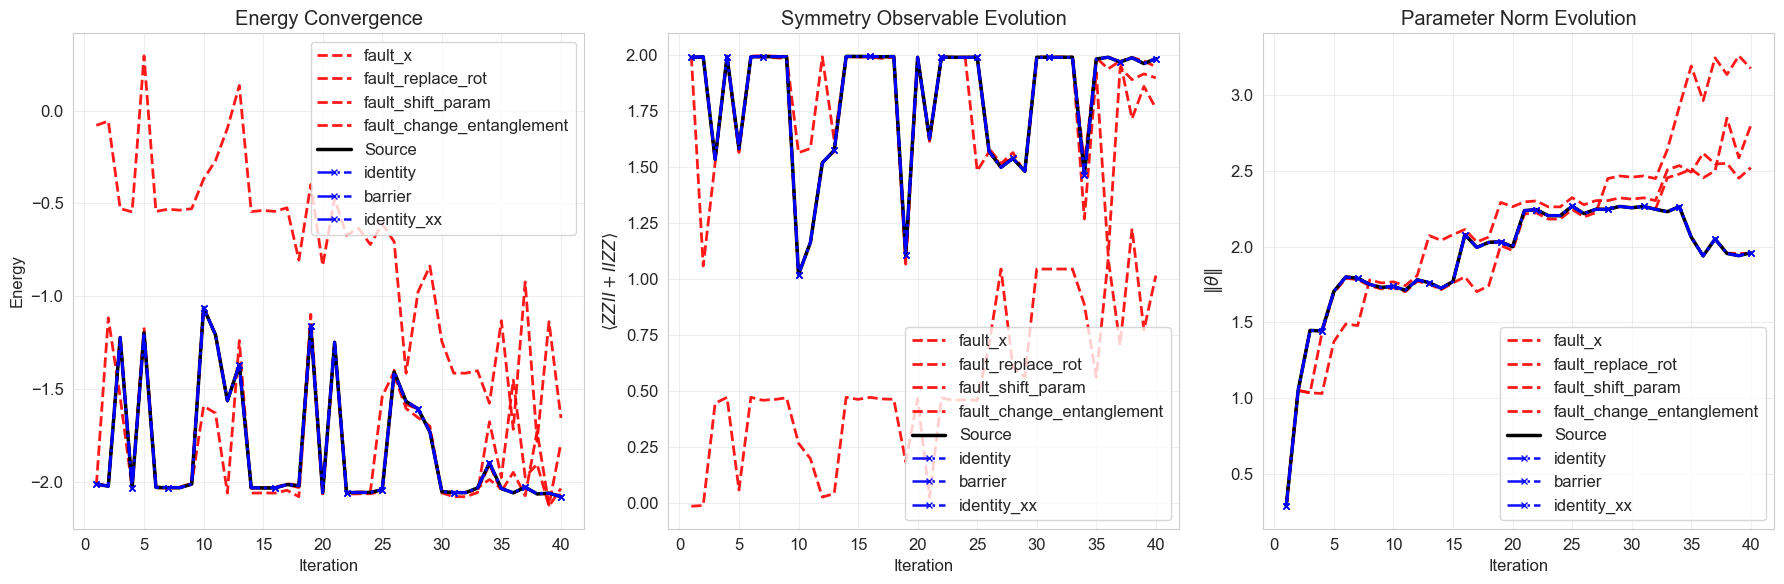

In [8]:
# FINAL VQE OPTIMIZATION PATHS

source_result, source_trace = run_vqe_trace(ansatz, H, symmetry_op, initial_point)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

followup_traces = []
for idx, (name, transform) in enumerate(relations.items()):
    try:
        follow_ansatz = transform(ansatz, seed=1000 + idx)
    except TypeError:
        follow_ansatz = transform(ansatz)

    _, follow_trace = run_vqe_trace(follow_ansatz, H, symmetry_op, initial_point)
    followup_traces.append((name, follow_trace))

valid_traces = [(name, tr) for name, tr in followup_traces if "fault" not in name]
fault_traces = [(name, tr) for name, tr in followup_traces if "fault" in name]

# Energy

for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.9,
        zorder=2
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4
    )

axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Energy")
axes[0].set_title("Energy Convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Symmetry 

for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.9,
        zorder=2
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4
    )

axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("Symmetry Observable Evolution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Parameter Norm 

for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.9,
        zorder=2
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4
    )

axes[2].set_xlabel("Iteration")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("Parameter Norm Evolution")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir/"vqe_optimization_paths.pdf", dpi=300, bbox_inches="tight")
plt.savefig(figures_dir/"vqe_optimization_paths.png", dpi=300, bbox_inches="tight")
plt.show()